# 01 — Mean-Variance: GMV & Tangency

The Markowitz core: the global minimum-variance portfolio and the
maximum-Sharpe (tangency) portfolio, the two long-only strategies every later
method in this repo is measured against.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

import maplab as ml
from maplab import Panel, apply_style
from maplab.models import tangency_closed_form

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

prices = ml.load_prices()
log_returns = ml.to_log_returns(prices)        # for estimation (mu, Sigma)
simple_returns = ml.to_simple_returns(prices)  # for compounding the backtest
panel = Panel({"prices": prices, "returns": log_returns})

print(f"prices: {prices.shape[0]:,} days × {prices.shape[1]} assets "
      f"({prices.index.min().date()} → {prices.index.max().date()})")

prices: 4,611 days × 26 assets (2008-01-02 → 2026-04-30)


## The math

**Unconstrained global minimum-variance (GMV):**

$$w_{\text{GMV}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}$$

**Unconstrained tangency (maximum Sharpe):**

$$w_{\text{tan}} = \frac{\Sigma^{-1}(\mu - r_f)}{\mathbf{1}'\Sigma^{-1}(\mu - r_f)}$$

**Two-fund separation:** every unconstrained mean-variance-efficient portfolio
is a combination of just these two funds, $w_{GMV}$ and $w_{tan}$ — no other
information from $\mu$ or $\Sigma$ is needed once you have them.

**Why the classes in `maplab.models` are long-only, not these closed forms:**
the unconstrained solutions above can (and, on this universe, do) put large
long and short positions on assets with noisy estimated means — leverage and
short exposure that a real long-only allocator can't take and that is mostly
estimation error, not signal. `GMV` and `MaxSharpe` solve the same objectives
numerically with $w \ge 0$ added, which is why they need `scipy.optimize`
rather than a one-line solve.

**$\mu$ estimation (log → arithmetic):** the harness estimates $(\mu, \Sigma)$
on **log** returns (additive, well-behaved) but scores strategies on
**arithmetic** (simple) returns. Feeding a log-return mean straight into a
mean-variance objective is systematically biased downward, so:

$$\mu = \overline{r_{\log}} \times 252 + \tfrac{1}{2}\,\text{diag}(\Sigma)$$

**Sharpe:** per the contract, `RF_ANNUAL = 0`, so Sharpe here is simply
$\text{return}/\text{vol}$ — there is no rate series to source or maintain.

## Snapshot at the train/test split

$(\mu, \Sigma)$ estimated at the last rebalance on or before
`TRAIN_TEST_SPLIT`, and what GMV, MaxSharpe, and the **unconstrained**
tangency portfolio each do with them. The unconstrained column is the
"why long-only" evidence: its largest longs and shorts, and its gross
leverage $\sum |w|$.

In [2]:
from maplab import GMV, MaxSharpe

rdates = ml.rebalance_dates(simple_returns.index)
split_ts = pd.Timestamp(ml.TRAIN_TEST_SPLIT)
split_rebal = rdates[rdates <= split_ts].max()
print(f"Snapshot date (last rebalance <= {ml.TRAIN_TEST_SPLIT}): {split_rebal.date()}")

gmv_snap = GMV()
mu, Sigma = gmv_snap._estimate(panel, split_rebal)

w_gmv = GMV()(panel, split_rebal)
w_msr = MaxSharpe()(panel, split_rebal)

try:
    w_tan = tangency_closed_form(mu, Sigma, rf=0.0)
    tan_undefined = False
except ValueError as e:
    tan_undefined = True
    tan_error = str(e)

cols = {"GMV (long-only)": w_gmv, "MaxSharpe (long-only)": w_msr}
if not tan_undefined:
    cols["Tangency (UNCONSTRAINED)"] = w_tan
snap = pd.DataFrame(cols).round(4)

leverage_msg = (f"Gross leverage sum|w|  —  GMV: {w_gmv.abs().sum():.3f}  "
                f"MaxSharpe: {w_msr.abs().sum():.3f}")
if not tan_undefined:
    leverage_msg += f"  Unconstrained tangency: {w_tan.abs().sum():.3f}"
print(leverage_msg)

if tan_undefined:
    print(f"\nUnconstrained tangency is UNDEFINED at this snapshot:\n  {tan_error}")
    print("(1'Σ⁻¹(μ−rf) = (1'Σ⁻¹1)(μ_GMV,unc − rf), and 1'Σ⁻¹1 > 0, so the "
          "denominator is negative iff the unconstrained GMV's own expected "
          "return is below rf — the tangency then lies on the inefficient "
          "branch of the hyperbola, not a numerically \"extreme\" point on "
          "the efficient one.)")
else:
    print("\nUnconstrained tangency — largest LONGS:")
    display(w_tan.sort_values(ascending=False).head(5).round(4).to_frame("weight"))
    print("Unconstrained tangency — largest SHORTS:")
    display(w_tan.sort_values().head(5).round(4).to_frame("weight"))

print("\nHoldings with any weight > 1e-4:")
mask = (snap.abs() > 1e-4).any(axis=1)
snap.loc[mask].sort_values("GMV (long-only)", ascending=False)

Snapshot date (last rebalance <= 2022-12-31): 2022-12-31
Gross leverage sum|w|  —  GMV: 1.000  MaxSharpe: 1.000

Unconstrained tangency is UNDEFINED at this snapshot:
  tangency_closed_form: denominator 1'Σ⁻¹(μ−rf) = np.float64(-109.86516400082351) <= 0
(1'Σ⁻¹(μ−rf) = (1'Σ⁻¹1)(μ_GMV,unc − rf), and 1'Σ⁻¹1 > 0, so the denominator is negative iff the unconstrained GMV's own expected return is below rf — the tangency then lies on the inefficient branch of the hyperbola, not a numerically "extreme" point on the efficient one.)

Holdings with any weight > 1e-4:


,GMV (long-only),MaxSharpe (long-only)
Ticker,,
SHY,0.9989,0.0000
XLE,0.0006,1.0000
USO,0.0005,0.0000


In [3]:
from maplab.models import gmv_closed_form

w_unc = gmv_closed_form(Sigma)
mu_gmv_unc = float(w_unc.to_numpy() @ mu.to_numpy())
ones_Sinv_ones = float(np.ones(len(mu)) @ np.linalg.solve(Sigma.to_numpy(), np.ones(len(mu))))
denom_from_identity = ones_Sinv_ones * (mu_gmv_unc - 0.0)

print(f"mu' w_unc (unconstrained GMV's own expected return): {mu_gmv_unc:.6f}  (< 0? {mu_gmv_unc < 0})")
print(f"1'Σ⁻¹1: {ones_Sinv_ones:.6f}")
print(f"(1'Σ⁻¹1) * (mu_GMV,unc - rf): {denom_from_identity:.6f}   vs.   raw denominator: -109.865164")
print(f"\nUnconstrained GMV gross leverage sum|w|: {w_unc.abs().sum():.3f}")
print("\nUnconstrained GMV — largest LONGS:")
display(w_unc.sort_values(ascending=False).head(5).round(4).to_frame("weight"))
print("Unconstrained GMV — largest SHORTS:")
display(w_unc.sort_values().head(5).round(4).to_frame("weight"))

mu' w_unc (unconstrained GMV's own expected return): -0.017582  (< 0? True)
1'Σ⁻¹1: 6248.700125
(1'Σ⁻¹1) * (mu_GMV,unc - rf): -109.865164   vs.   raw denominator: -109.865164

Unconstrained GMV gross leverage sum|w|: 2.105

Unconstrained GMV — largest LONGS:


,weight
Ticker,
SHY,1.3703
TLT,0.0996
XLF,0.0141
IWM,0.0135
EEM,0.0108


Unconstrained GMV — largest SHORTS:


,weight
Ticker,
IEF,-0.3282
AGG,-0.1167
SPY,-0.0373
HYG,-0.0290
GLD,-0.0203


## The long-only efficient frontier

At the same snapshot date: sweep a target return, minimize variance subject
to $w'\mu = \text{target}$, $\sum w = 1$, $w \ge 0$ (SLSQP with analytic
gradients). The 26 assets are shown as labeled dots, GMV and MaxSharpe are
marked, and the capital market line (CML) runs from $r_f = 0$ through
MaxSharpe. $\mu$ here is the trailing-252-day arithmetic mean, so the
tangency lands on last year's best asset.

The grey backdrop is 20,000 random long-only portfolios drawn from a
Dirichlet($\alpha=0.1$) distribution: Dirichlet(1), the textbook choice on 6
assets, collapses toward 1/N at 26 assets (median effective N $\approx$ 14,
max weight $\approx$ 14%) and never reaches the corners where GMV and
MaxSharpe live; $\alpha=0.1$ on 26 assets gives roughly the spread
$\alpha=1$ gives on 6.

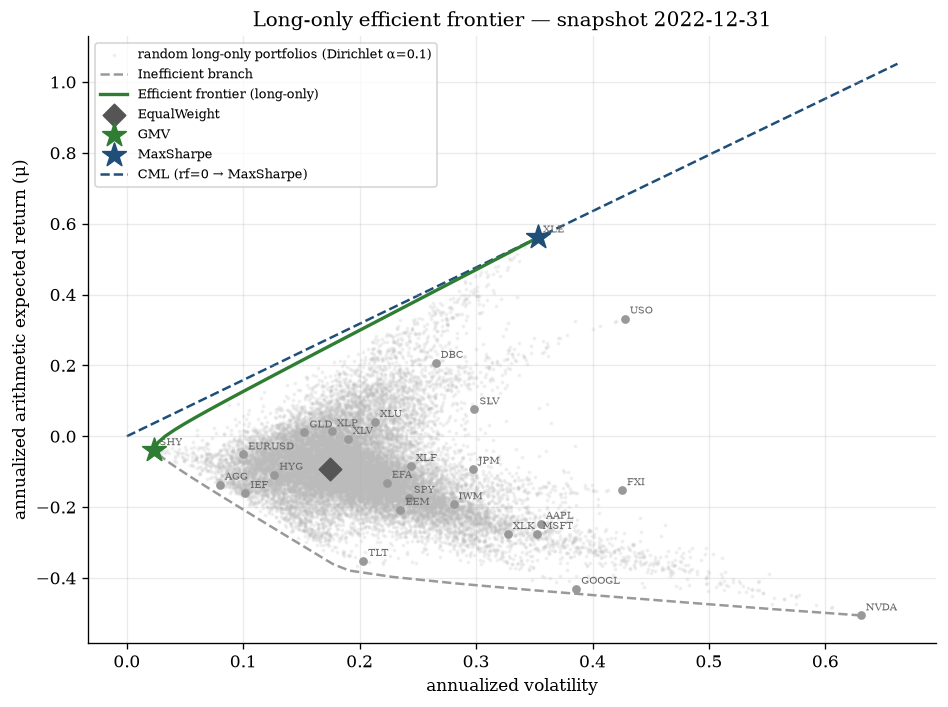

In [4]:
def min_variance_at_target(Sigma: pd.DataFrame, mu: pd.Series, target: float, x0: np.ndarray) -> np.ndarray:
    n = Sigma.shape[0]
    Sigma_np = Sigma.to_numpy()
    mu_np = mu.to_numpy()
    ones = np.ones(n)
    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1.0, "jac": lambda w: ones},
        {"type": "eq", "fun": lambda w: w @ mu_np - target, "jac": lambda w: mu_np},
    ]
    bounds = [(0.0, 1.0)] * n
    res = opt.minimize(
        lambda w: w @ Sigma_np @ w, x0, jac=lambda w: 2 * Sigma_np @ w, method="SLSQP",
        bounds=bounds, constraints=cons, options={"ftol": 1e-12, "maxiter": 1000},
    )
    if not res.success:
        return None
    return res.x

n = len(ml.UNIVERSE)
Sigma_np = Sigma.to_numpy()
mu_np = mu.to_numpy()

# Monte Carlo backdrop: 20,000 random long-only portfolios, Dirichlet(0.1)
rng_mc = np.random.default_rng(7)
mc_weights = rng_mc.dirichlet(np.full(n, 0.1), size=20_000)
mc_ret = mc_weights @ mu_np
mc_vol = np.sqrt(np.einsum("ij,jk,ik->i", mc_weights, Sigma_np, mc_weights))

targets = np.linspace(mu.min(), mu.max(), 60)
x0 = np.full(n, 1.0 / n)
frontier_ret, frontier_vol = [], []
for t in targets:
    w = min_variance_at_target(Sigma, mu, t, x0)
    if w is None:
        continue
    x0 = w  # warm start the next point
    frontier_ret.append(w @ mu_np)
    frontier_vol.append(np.sqrt(w @ Sigma_np @ w))
frontier_ret = np.array(frontier_ret)
frontier_vol = np.array(frontier_vol)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(mc_vol, mc_ret, s=2, alpha=0.15, color="#bbbbbb", zorder=0,
           label="random long-only portfolios (Dirichlet α=0.1)")

asset_vol = np.sqrt(np.diag(Sigma_np))
ax.scatter(asset_vol, mu_np, s=18, color="#999999", zorder=2)
for i, tkr in enumerate(ml.UNIVERSE):
    ax.annotate(tkr, (asset_vol[i], mu_np[i]), fontsize=6,
                xytext=(3, 3), textcoords="offset points", color="#666666")

gmv_ret = float(w_gmv.to_numpy() @ mu_np)
gmv_vol = float(np.sqrt(w_gmv.to_numpy() @ Sigma_np @ w_gmv.to_numpy()))
msr_ret = float(w_msr.to_numpy() @ mu_np)
msr_vol = float(np.sqrt(w_msr.to_numpy() @ Sigma_np @ w_msr.to_numpy()))

# Efficient (return >= GMV's) vs inefficient branch of the swept curve
efficient = frontier_ret >= gmv_ret
ax.plot(frontier_vol[~efficient], frontier_ret[~efficient], color="#999999",
        ls="--", lw=1.5, zorder=3, label="Inefficient branch")
ax.plot(frontier_vol[efficient], frontier_ret[efficient], color="#2e7d32",
        lw=2, zorder=3, label="Efficient frontier (long-only)")

ew_w = np.full(n, 1.0 / n)
ew_ret = float(ew_w @ mu_np)
ew_vol = float(np.sqrt(ew_w @ Sigma_np @ ew_w))
ax.scatter([ew_vol], [ew_ret], marker="D", s=90,
           color=ml.FAMILY_COLORS["Benchmark"], zorder=4, label="EqualWeight")

ax.scatter([gmv_vol], [gmv_ret], marker="*", s=220,
           color=ml.FAMILY_COLORS[GMV.family], zorder=4, label="GMV")
ax.scatter([msr_vol], [msr_ret], marker="*", s=220,
           color=ml.FAMILY_COLORS[MaxSharpe.family], zorder=4, label="MaxSharpe")

cml_x = np.linspace(0, max(asset_vol.max(), msr_vol, mc_vol.max()) * 1.05, 20)
cml_slope = (msr_ret - 0.0) / msr_vol
ax.plot(cml_x, cml_slope * cml_x, color="#1f4e79", ls="--", lw=1.5,
        zorder=1, label="CML (rf=0 → MaxSharpe)")

ax.set_xlabel("annualized volatility")
ax.set_ylabel("annualized arithmetic expected return (μ)")
ax.set_title(f"Long-only efficient frontier — snapshot {split_rebal.date()}")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## Backtest: GMV, MaxSharpe, EqualWeight

Fresh strategy instances run through `ml.backtest` (default scoring start —
the first eligible rebalance after the 252-day warm-up). `ml.summary` over
the full sample, the train window ($\le$ `TRAIN_TEST_SPLIT`), and the held-out
test window (> split).

In [5]:
from maplab import EqualWeight, backtest, summary

strategies = {"GMV": GMV(), "MaxSharpe": MaxSharpe(), "EqualWeight": EqualWeight()}

results = {}
for name, strat in strategies.items():
    net, wlog, diag = backtest(strat, simple_returns, panel)
    results[name] = {"net": net, "wlog": wlog, "diag": diag}

split_ts = pd.Timestamp(ml.TRAIN_TEST_SPLIT)

rows = []
for name, r in results.items():
    net = r["net"]
    turnover = r["diag"]["turnover_per_rebalance"]
    windows = {
        "full": (net.index >= net.index.min(), turnover.index >= turnover.index.min()),
        "train (<= split)": (net.index <= split_ts, turnover.index <= split_ts),
        "test (> split)": (net.index > split_ts, turnover.index > split_ts),
    }
    for window_name, (net_sel, t_sel) in windows.items():
        s = summary(net.loc[net_sel], turnover.loc[t_sel])
        s["strategy"] = name
        s["window"] = window_name
        rows.append(s)

summary_table = pd.DataFrame(rows).set_index(["strategy", "window"])
summary_table = summary_table[["ann_return", "ann_vol", "sharpe", "max_dd", "calmar", "hit_rate", "ann_turnover"]]

msr = strategies["MaxSharpe"]
print(f"MaxSharpe fallback_dates: {len(msr.fallback_dates)}   retry_dates: {len(msr.retry_dates)}")

summary_table.round(4)

MaxSharpe fallback_dates: 0   retry_dates: 0


ann_return  ann_vol  sharpe  max_dd  calmar  \
strategy    window                                                          
GMV         full                  0.0173   0.0133  1.3041 -0.0603  0.2874   
            train (<= split)      0.0098   0.0112  0.8701 -0.0603  0.1619   
            test (> split)        0.0491   0.0196  2.5033 -0.0144  3.4019   
MaxSharpe   full                  0.0558   0.0879  0.6348 -0.2178  0.2561   
            train (<= split)      0.0455   0.0793  0.5737 -0.2178  0.2089   
            test (> split)        0.0990   0.1172  0.8442 -0.1743  0.5680   
EqualWeight full                  0.1333   0.1300  1.0255 -0.2598  0.5132   
            train (<= split)      0.1168   0.1352  0.8643 -0.2598  0.4497   
            test (> split)        0.2026   0.1054  1.9212 -0.1226  1.6522   

                              hit_rate  ann_turnover  
strategy    window                                    
GMV         full                0.5567        0.0982  
            train (<= split)    0.5505        0.0901  
            test (> split)      0.5827        0.1356  
MaxSharpe   full                0.5689        2.3305  
            train (<= split)    0.5665        2.4125  
            test (> split)      0.5791        2.0028  
EqualWeight full                0.5586        0.2151  
            train (<= split)    0.5551        0.2138  
            test (> split)      0.5731        0.2194

## Allocation through time

Target weights from each strategy's `wlog`, aggregated by `ml.GROUP_OF` into
the 6 asset groups, at every rebalance.

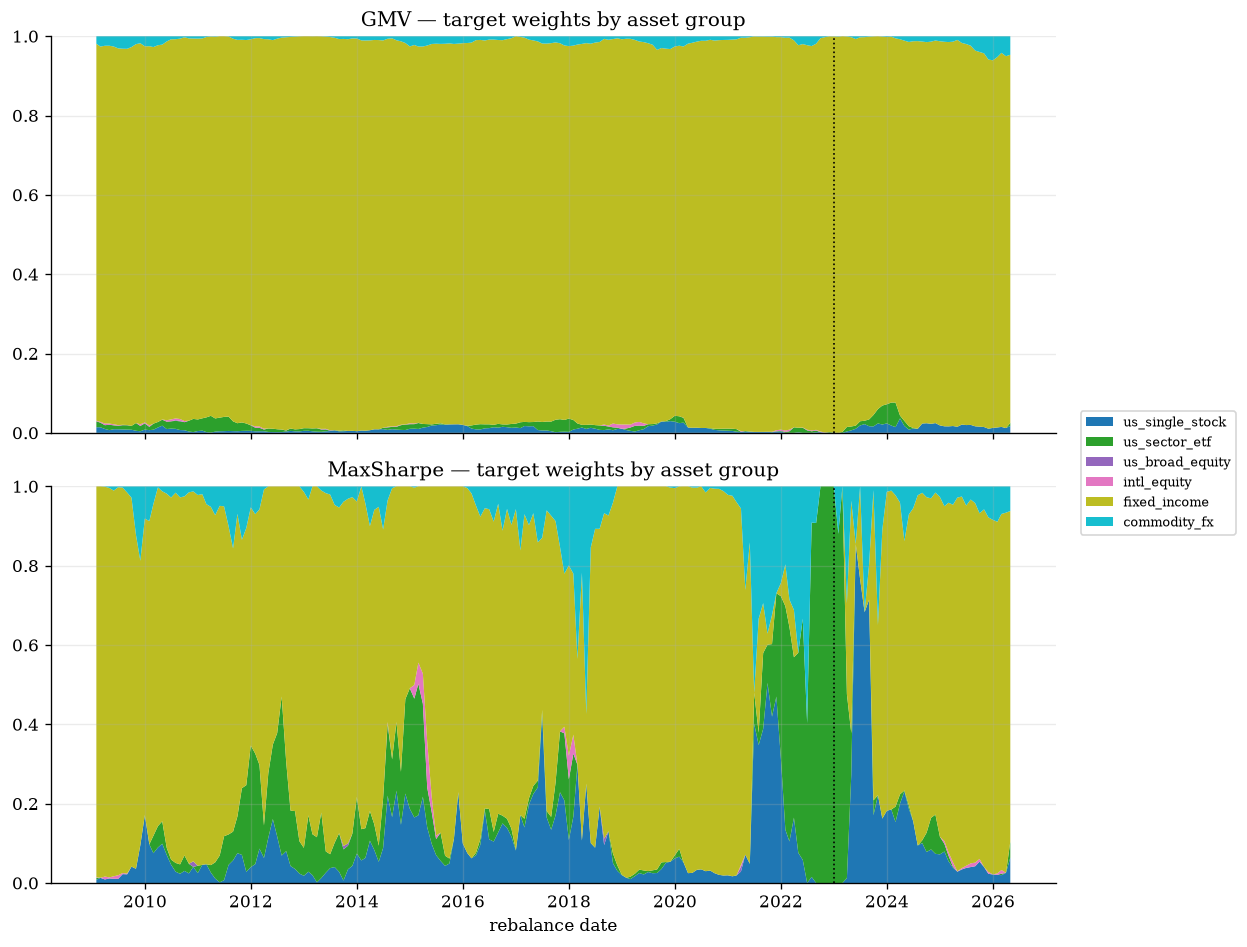

GMV: SHY weight  mean=0.9631  min=0.9183  max=0.9989   |   fixed_income weight mean=0.9665
MaxSharpe: SHY weight  mean=0.5570  min=0.0000  max=0.9793   |   fixed_income weight mean=0.7152


In [6]:
group_order = list(ml.ASSET_GROUPS.keys())
group_colors = plt.cm.tab10(np.linspace(0, 1, len(group_order)))

def weights_by_group(wlog):
    grouped = wlog.T.groupby(ml.GROUP_OF).sum().T
    return grouped.reindex(columns=group_order).fillna(0.0)

gmv_group = weights_by_group(results["GMV"]["wlog"])
msr_group = weights_by_group(results["MaxSharpe"]["wlog"])

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for ax, grouped, title in zip(axes, [gmv_group, msr_group], ["GMV", "MaxSharpe"]):
    ax.stackplot(grouped.index, grouped.T.to_numpy(), labels=group_order, colors=group_colors)
    ax.axvline(split_ts, color="black", ls=":", lw=1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title} — target weights by asset group")
axes[-1].set_xlabel("rebalance date")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

for name in ["GMV", "MaxSharpe"]:
    shy_w = results[name]["wlog"]["SHY"]
    fi_w = weights_by_group(results[name]["wlog"])["fixed_income"]
    print(f"{name}: SHY weight  mean={shy_w.mean():.4f}  min={shy_w.min():.4f}  max={shy_w.max():.4f}"
          f"   |   fixed_income weight mean={fi_w.mean():.4f}")

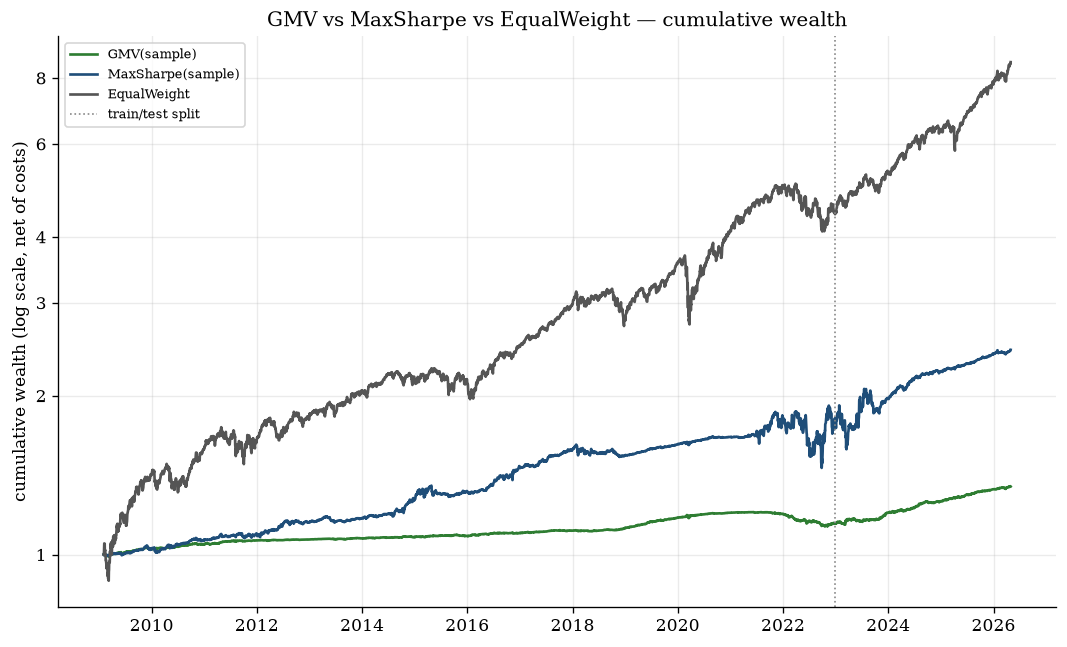

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, strat in strategies.items():
    net = results[name]["net"]
    wealth = (1.0 + net).cumprod()
    color = ml.FAMILY_COLORS[strat.family]
    ax.plot(wealth.index, wealth.to_numpy(), label=strat.label, color=color, lw=1.6)

ax.axvline(split_ts, color="#888888", ls=":", lw=1, label="train/test split")
ax.set_yscale("log")
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter, NullLocator
ymin, ymax = ax.get_ylim()
candidate_ticks = [1, 2, 3, 4, 6, 8]
yticks = [t for t in candidate_ticks if ymin <= t <= ymax]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_ylabel("cumulative wealth (log scale, net of costs)")
ax.set_title("GMV vs MaxSharpe vs EqualWeight — cumulative wealth")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

TAKEAWAY

GMV collapses into short Treasuries (mean 96.3% SHY, range 91.8–99.9%): 1.7% return, 1.3% vol, −6% max DD, ~10% turnover. Its full-sample Sharpe of 1.30 needs the RF = 0 caveat: pre-2023 it is essentially tied with 1/N (0.87 vs 0.86), and the 2023+ jump (2.50) is largely short-rate carry, not diversification skill.
MaxSharpe with a 252-day sample μ is an error maximizer. It jumps between SHY and single-asset corners (100% XLE at end-2022), turns over ~233% a year, and has the worst risk-adjusted result in both windows (0.57 train, 0.84 test) with a −22% drawdown.
Naive 1/N beats MaxSharpe in every window and matches GMV pre-2023, at 13% vol instead of 1%.
The unconstrained tangency isn't even defined at end-2022: the unconstrained GMV had negative expected return, so the formula points to the inefficient branch. Long-only isn't a cosmetic constraint here.
Caveats: one historical path, no confidence intervals, so this is consistent with the literature, not proof. What fails is sample-mean μ, not mean-variance as such. Better μ (03, Black-Litterman) and better Σ (04, shrinkage) are the next steps.